In [12]:
import requests

# URL of the raw SMSSpamCollection file on GitHub
url = 'https://raw.githubusercontent.com/krishnaik06/SpamClassifier/master/smsspamcollection/SMSSpamCollection'

# Define the local path to save the file
local_file_path = 'SMSSpamCollection'

# Download the file
response = requests.get(url)
response.raise_for_status() # Raise an exception for bad status codes

with open(local_file_path, 'wb') as f:
    f.write(response.content)

print(f"File downloaded successfully to {local_file_path}")

File downloaded successfully to SMSSpamCollection


In [13]:
# importing the Dataset

import pandas as pd

messages = pd.read_csv('/content/SMSSpamCollection', sep='\t',  #t used because this file is tab separated
                           names=["label", "message"])

In [14]:
messages

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [15]:
#Data cleaning and preprocessing
import re
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [16]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
corpus = []
for i in range(0, len(messages)):
    review = re.sub('[^a-zA-Z]', ' ', messages['message'][i])
    review = review.lower()
    review = review.split()

    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)

In [18]:
corpus

['go jurong point crazi avail bugi n great world la e buffet cine got amor wat',
 'ok lar joke wif u oni',
 'free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli',
 'u dun say earli hor u c alreadi say',
 'nah think goe usf live around though',
 'freemsg hey darl week word back like fun still tb ok xxx std chg send rcv',
 'even brother like speak treat like aid patent',
 'per request mell mell oru minnaminungint nurungu vettam set callertun caller press copi friend callertun',
 'winner valu network custom select receivea prize reward claim call claim code kl valid hour',
 'mobil month u r entitl updat latest colour mobil camera free call mobil updat co free',
 'gonna home soon want talk stuff anymor tonight k cri enough today',
 'six chanc win cash pound txt csh send cost p day day tsandc appli repli hl info',
 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd pobox ldnw rw',
 'search right word thank breather

In [26]:
# Creating the Bag of Words model
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=2500) # if we do not give max_features it will take all unique characters. We should select just some
#frequent words, so we took 2500 as random word size.
X = cv.fit_transform(corpus).toarray()

# changing output data in numeric format
# we will use dummy variables
# it creates tables with 0s and 1s based on labels. so wherewhere that lable present it gives value 1 else 0
# but in our case we have only two category ham or spam so we can take only one column for consideration, 1 will be ham 0 will be spam
y=pd.get_dummies(messages['label'])
y=y.iloc[:,1].values # removed column of ham



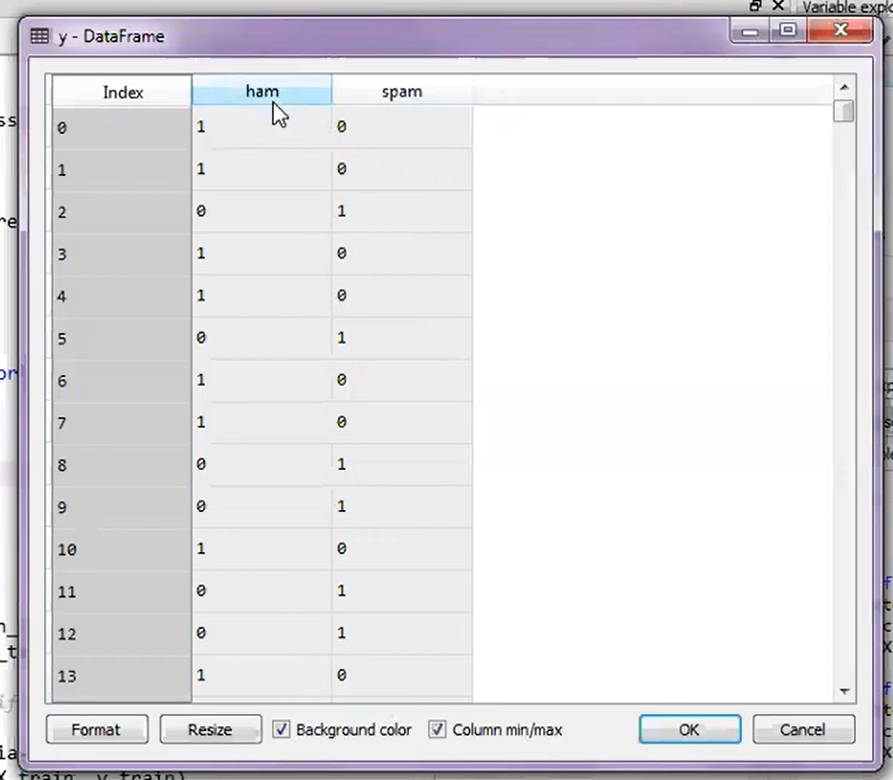

In [27]:
# Train Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

In [23]:
 #Training model using Naive bayes classifier
 # Naive bayes works very well with NLP problems. It is classification technique and it works on probability.


from sklearn.naive_bayes import MultinomialNB
spam_detect_model = MultinomialNB().fit(X_train, y_train)

In [24]:
y_pred=spam_detect_model.predict(X_test)

In [29]:
# confusion matrix for evaluation
from sklearn.metrics import confusion_matrix #2X2 matrix
confusion_m=confusion_matrix(y_test,y_pred)

In [30]:
print(confusion_m)

[[947   8]
 [  7 153]]


In [32]:
#accuracy matrix
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)

In [33]:
print(accuracy)

0.9865470852017937
